# Quantum Teleportation Walkthrough

This notebook builds the teleportation circuit **one protocol step at a time**,
showing the circuit diagram and the qubit states at each stage, then verifies
correctness with a statevector fidelity check (not just a raw measurement histogram).

**What teleportation does:** moves an unknown single-qubit state |ψ⟩ from one
qubit to another, using one shared entangled pair (a Bell pair) plus **two
classical bits** sent over an ordinary classical channel.

**What it does NOT do:**
- No faster-than-light communication — Bob cannot recover |ψ⟩ until Alice's
  two classical bits arrive.
- No cloning — the original qubit's state is destroyed by Alice's measurement
  (consistent with the no-cloning theorem).


In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt

THETA = 0.9  # angle used to prepare the arbitrary state |ψ⟩ = Rx(THETA)|0⟩


## Step 0 — Prepare the unknown state |ψ⟩

We put qubit **q0** into an arbitrary state using an `Rx` rotation. In a real
scenario, Alice wouldn't know this state either — that's the whole point:
teleportation moves a state without anyone needing to know what it is.


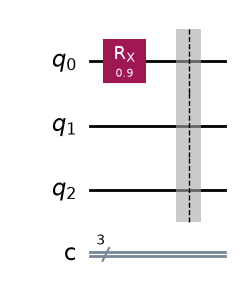

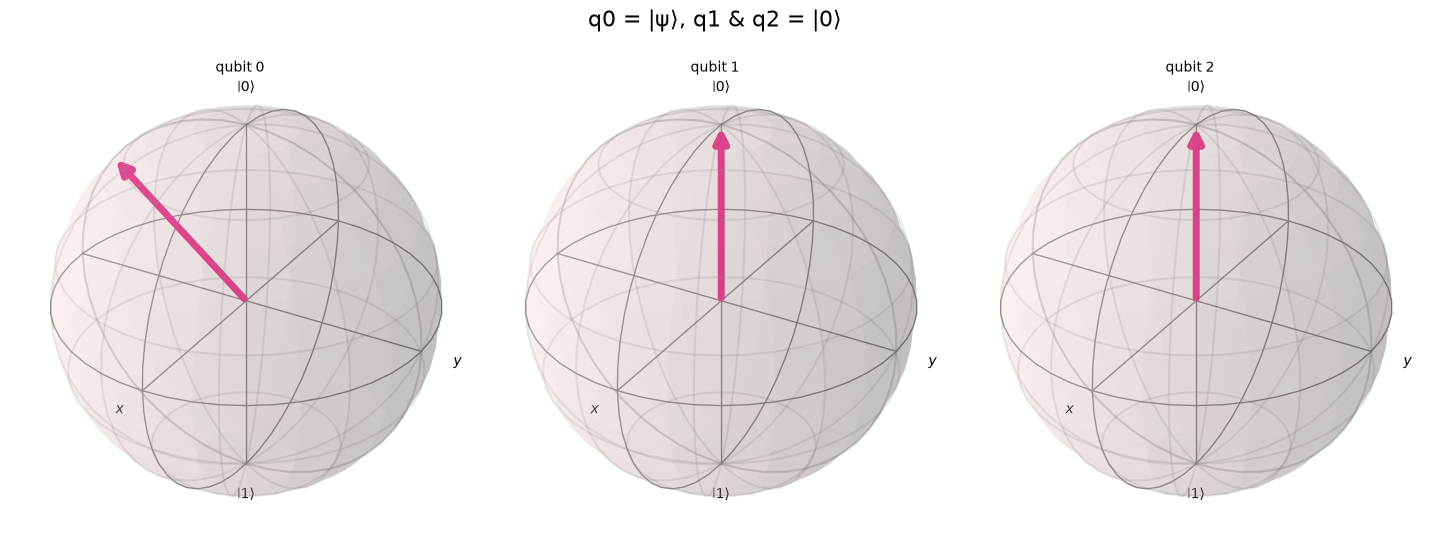

In [2]:
step0 = QuantumCircuit(3, 3)
step0.rx(THETA, 0)
step0.barrier()
display(step0.draw('mpl'))

psi = Statevector.from_instruction(step0)
plot_bloch_multivector(psi, title="q0 = |ψ⟩, q1 & q2 = |0⟩")


## Step 1 — Create a Bell pair (the entanglement resource)

Alice and Bob each hold one half of an entangled pair: **q1** (Alice) and
**q2** (Bob). This pair must be created and distributed *before* Alice knows
anything about |ψ⟩ — it's the shared resource the protocol consumes.


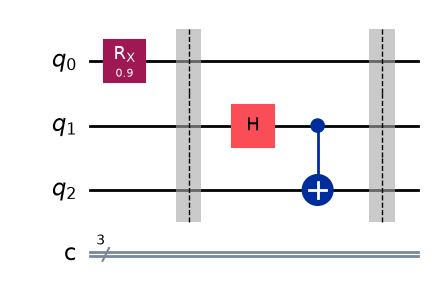

In [3]:
step1 = step0.copy()
step1.h(1)
step1.cx(1, 2)
step1.barrier()
display(step1.draw('mpl'))


## Step 2 — Alice entangles her unknown qubit with her half of the pair

Alice applies a CNOT then a Hadamard between **q0** (|ψ⟩) and **q1** (her half
of the Bell pair). This rotates the 3-qubit state into the Bell basis so that
a simple 2-qubit measurement will reveal exactly which correction Bob needs.


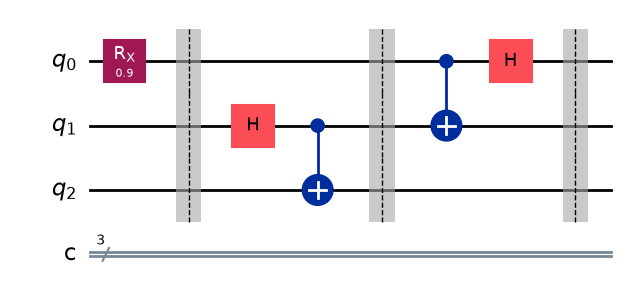

In [4]:
step2 = step1.copy()
step2.cx(0, 1)
step2.h(0)
step2.barrier()
display(step2.draw('mpl'))


## Step 3 — Alice measures q0 and q1

Alice measures her two qubits, producing two classical bits `m0`, `m1`. This
collapses the state — |ψ⟩ no longer exists on q0. Every one of the 4 possible
outcomes is equally likely (25% each), and **which one occurs is random** —
that randomness is exactly what carries no usable information on its own.

Alice sends `m0` and `m1` to Bob over a classical channel (phone, internet,
carrier pigeon — anything classical works, but it isn't instantaneous).


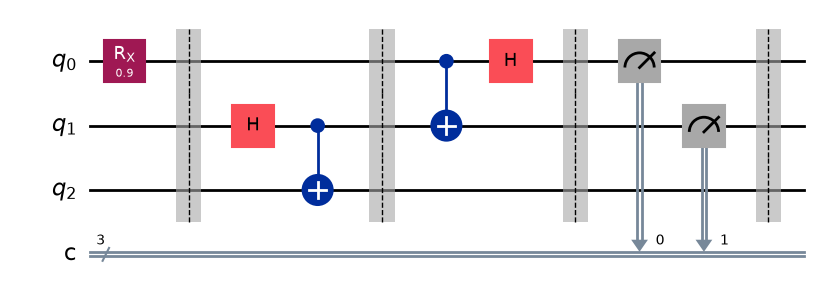

In [5]:
step3 = step2.copy()
step3.measure(0, 0)
step3.measure(1, 1)
step3.barrier()
display(step3.draw('mpl'))


## Step 4 — Bob applies a correction conditioned on the classical bits

Depending on `(m0, m1)`, Bob's qubit q2 is in one of four states, each equal to
|ψ⟩ up to a known Pauli correction:

| m0 | m1 | Bob's correction |
|----|----|-------------------|
| 0  | 0  | none |
| 0  | 1  | X |
| 1  | 0  | Z |
| 1  | 1  | X then Z |

He applies `X` if `m1 == 1` and `Z` if `m0 == 1`, using Qiskit's classical
control-flow (`if_test`) — the modern replacement for the deprecated `.c_if()`.


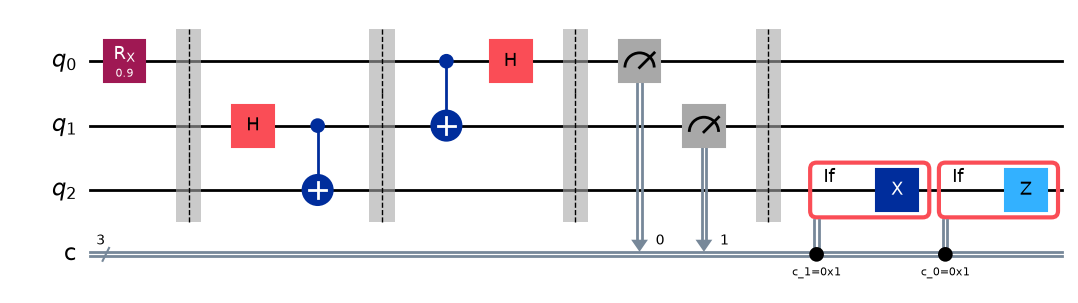

In [6]:
from main import quantum_teleportation, verify_fidelity

full_circuit = quantum_teleportation(THETA)
display(full_circuit.draw('mpl'))


## Does it actually work? — Raw measurement counts

Running the circuit many times and reading out **all three** classical bits
gives a mixed histogram — this alone is *not* proof of teleportation, since
Alice's two bits are always uniformly random regardless of whether the
protocol is correct. Watch how q2's bit correlates with (m0, m1): it always
represents the correctly-corrected |ψ⟩, but you can't see that from counts alone.


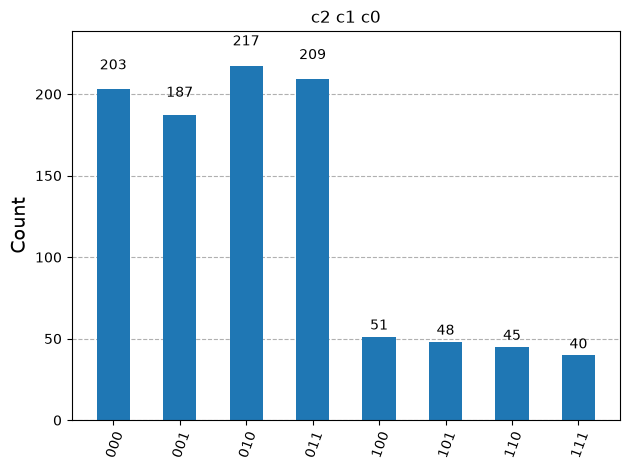

In [7]:
demo = quantum_teleportation(THETA)
demo.measure(2, 2)
sim = AerSimulator()
result = sim.run(transpile(demo, sim), shots=1000).result()
plot_histogram(result.get_counts(), title="c2 c1 c0")


## Proper verification — statevector fidelity

The real test: for **every** measurement outcome Alice can get, does Bob's
corrected qubit end up in exactly |ψ⟩? We simulate the full statevector
(instead of just sampling bits), trace out Alice's two qubits, and compute
the **fidelity** between Bob's reduced state and the original |ψ⟩.

A fidelity of `1.0` means an exact match — teleportation succeeded regardless
of which of the 4 random outcomes occurred.


Fidelities over 30 independent trials:
  min = 1.000000
  max = 1.000000
  all == 1.0? True


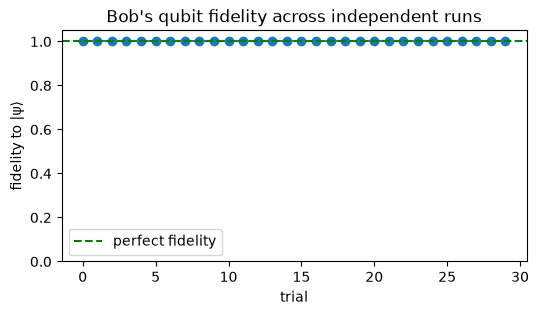

In [8]:
fidelities = verify_fidelity(theta=THETA, trials=30)
print(f"Fidelities over {len(fidelities)} independent trials:")
print(f"  min = {min(fidelities):.6f}")
print(f"  max = {max(fidelities):.6f}")
print(f"  all == 1.0? {all(f > 0.999999 for f in fidelities)}")

plt.figure(figsize=(6, 3))
plt.plot(fidelities, 'o-')
plt.ylim(0, 1.05)
plt.axhline(1.0, color='green', linestyle='--', label='perfect fidelity')
plt.xlabel('trial')
plt.ylabel('fidelity to |ψ⟩')
plt.title('Bob\'s qubit fidelity across independent runs')
plt.legend()
plt.show()


## Sanity check across different input states

To show this isn't a fluke tied to one particular angle, repeat the fidelity
check for several different |ψ⟩ states.


In [9]:
import numpy as np

test_angles = np.linspace(0, np.pi, 6)
for angle in test_angles:
    fids = verify_fidelity(theta=angle, trials=10)
    print(f"theta={angle:.3f} rad -> min fidelity={min(fids):.6f}")


theta=0.000 rad -> min fidelity=1.000000


theta=0.628 rad -> min fidelity=1.000000


theta=1.257 rad -> min fidelity=1.000000


theta=1.885 rad -> min fidelity=1.000000


theta=2.513 rad -> min fidelity=1.000000


theta=3.142 rad -> min fidelity=1.000000


## Key talking points for Q&A

- **No faster-than-light signaling**: Bob's qubit isn't usable as |ψ⟩ until he
  receives Alice's classical bits and applies the correction — the classical
  channel is the bottleneck, so causality is preserved.
- **No-cloning respected**: the original |ψ⟩ on q0 is destroyed by Alice's
  measurement; there's never two copies of |ψ⟩ at once.
- **What's actually "teleported"**: not matter or energy — only the quantum
  *information* (the state), via consuming one Bell pair and two classical bits.
- **Why fidelity, not counts**: raw measurement counts of all 3 bits look
  "random" either way; the fidelity check isolates whether Bob's corrected
  qubit matches |ψ⟩, which is the actual claim being tested.
